In [1]:
!pip install shap
!pip install lime
!pip install scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0b1c18cb301ab41652713547c4ec11268f676dfa49cc430240f3eb4052125189
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from shap import DeepExplainer
from lime import lime_image
from skimage.segmentation import mark_boundaries

# 1. Preparación del Dataset (MNIST)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalizar y redimensionar para la CNN (añadir canal de color)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Convertir etiquetas a categorical
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
import tensorflow as tf

print(tf.__version__)
print("Eager:", tf.executing_eagerly())

print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))

2.20.0
Eager: True
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ==========================================
# 2. CONSTRUCCIÓN Y ENTRENAMIENTO DE LA CNN
# ==========================================
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Entrenando la CNN...")

history = model.fit(
    x_train,
    y_train_cat,
    epochs=2,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# ==========================================
# IMAGEN A EXPLICAR
# ==========================================
idx = 0

img_to_explain = x_test[idx]
true_label = y_test[idx]

# Predicción
pred = model.predict(
    np.expand_dims(img_to_explain, axis=0),
    verbose=0
)

pred_label = np.argmax(pred)

print(f"Clase real: {true_label}")
print(f"Predicción: {pred_label}")
print(f"Probabilidad: {pred[0][pred_label]:.4f}")

Entrenando la CNN...
Epoch 1/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9265 - loss: 0.2531 - val_accuracy: 0.9787 - val_loss: 0.0739
Epoch 2/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9799 - loss: 0.0639 - val_accuracy: 0.9852 - val_loss: 0.0532
Clase real: 7
Predicción: 7
Probabilidad: 0.9999


In [5]:
# 3. Explicación con SHAP (DeepExplainer)
print("\nCalculando SHAP values...")

import shap
import numpy as np
import tensorflow as tf

# 1. Función de predicción: Bypass a model.predict()
def predict_fn_image(images):
    # En lugar de usar .predict(), convertimos a tensor y llamamos al modelo directamente.
    # Esto evita por completo el uso de tf.data.Dataset y no lanza el RuntimeError.
    tensor_images = tf.convert_to_tensor(images, dtype=tf.float32)
    preds = model(tensor_images, training=False)

    # Si estamos en un grafo estricto por el disable_eager previo, forzamos la evaluación:
    if not tf.executing_eagerly():
        with tf.compat.v1.Session() as sess:
            sess.run(tf.compat.v1.global_variables_initializer())
            return sess.run(preds)
    return preds.numpy()

# 2. Inyectar explícitamente el arreglo de ceros
background_mask = np.zeros((28, 28, 1), dtype=np.float32)
masker = shap.maskers.Image(background_mask, shape=(28, 28, 1))

# 3. Instanciar el Explainer
explainer_shap = shap.Explainer(predict_fn_image, masker, output_names=[str(i) for i in range(10)])

# 4. Preparar la entrada
img_input = np.expand_dims(img_to_explain, axis=0)

# 5. Calcular SHAP values
shap_values_img = explainer_shap(img_input, max_evals=500, batch_size=50)

# 6. Extraer la matriz
shap_img = shap_values_img.values[0, :, :, 0, pred_label]

print(f"SHAP calculado correctamente. Forma: {shap_img.shape}")


Calculando SHAP values...
SHAP calculado correctamente. Forma: (28, 28)


In [6]:
# 4. Explicación con LIME (LimeImageExplainer)

print("Calculando LIME...")
explainer_lime = lime_image.LimeImageExplainer()

# LIME nativamente trabaja con imágenes RGB (3 canales).
# Para MNIST (escala de grises), duplicamos el canal para simular RGB en la función de predicción.
img_rgb = np.repeat(img_to_explain, 3, axis=-1)

def predict_fn(images):
    # Convertir de RGB de vuelta a escala de grises para que la CNN lo entienda
    grayscale_images = images[:, :, :, 0:1]
    return model.predict(grayscale_images)

explanation = explainer_lime.explain_instance(
    img_rgb,
    predict_fn,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)

# Obtener la máscara para la clase predicha
temp, mask = explanation.get_image_and_mask(
    pred_label,
    positive_only=False,
    num_features=10,
    hide_rest=False
)



Calculando LIME...


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━

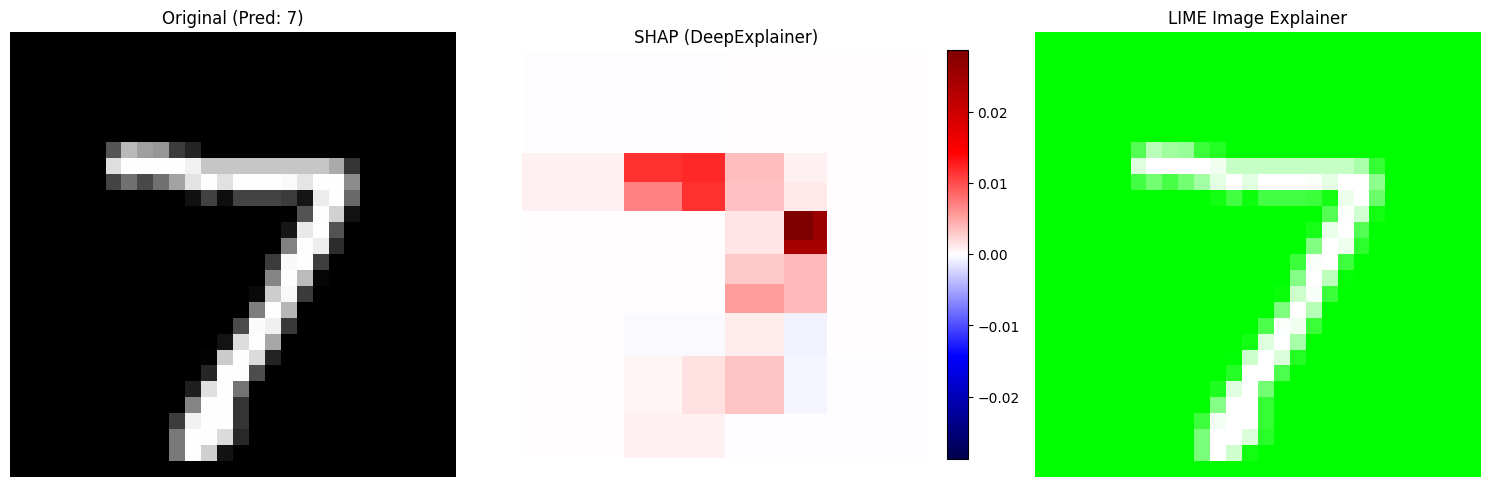

In [7]:
# 5. Visualización Comparativa

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Imagen Original
axes[0].imshow(img_to_explain.squeeze(), cmap='gray')
axes[0].set_title(f"Original (Pred: {pred_label})")
axes[0].axis('off')

# Visualización SHAP
# Los valores positivos (rojo) apoyan la predicción, los negativos (azul) van en contra
v_max = np.max(np.abs(shap_img))
im_shap = axes[1].imshow(shap_img, cmap='seismic', vmin=-v_max, vmax=v_max)
axes[1].set_title("SHAP (DeepExplainer)")
axes[1].axis('off')
fig.colorbar(im_shap, ax=axes[1], fraction=0.046, pad=0.04)

# Visualización LIME
# Verde: zonas que aportan positivamente a la predicción; Rojo: zonas en contra
axes[2].imshow(mark_boundaries(temp, mask))
axes[2].set_title("LIME Image Explainer")
axes[2].axis('off')

plt.tight_layout()
plt.show()